# Handwritten Digit Recognition Using Machine Learning

MNIST-based comparison of MLP, SVM (RBF) and KNN. The notebook follows the methodology documented in the project report.

## 1. Imports and Functions

The complete reusable implementation is in `src/train.py`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from train import *

## 2. Load MNIST

In [2]:
x_train_raw, y_train, x_test_raw, y_test = load_dataset()

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


## 3. Visualize Samples and Class Distribution

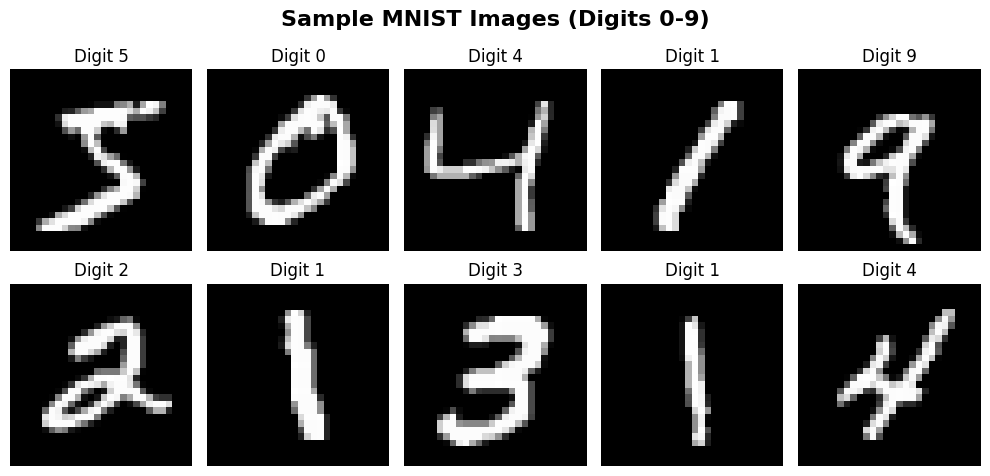

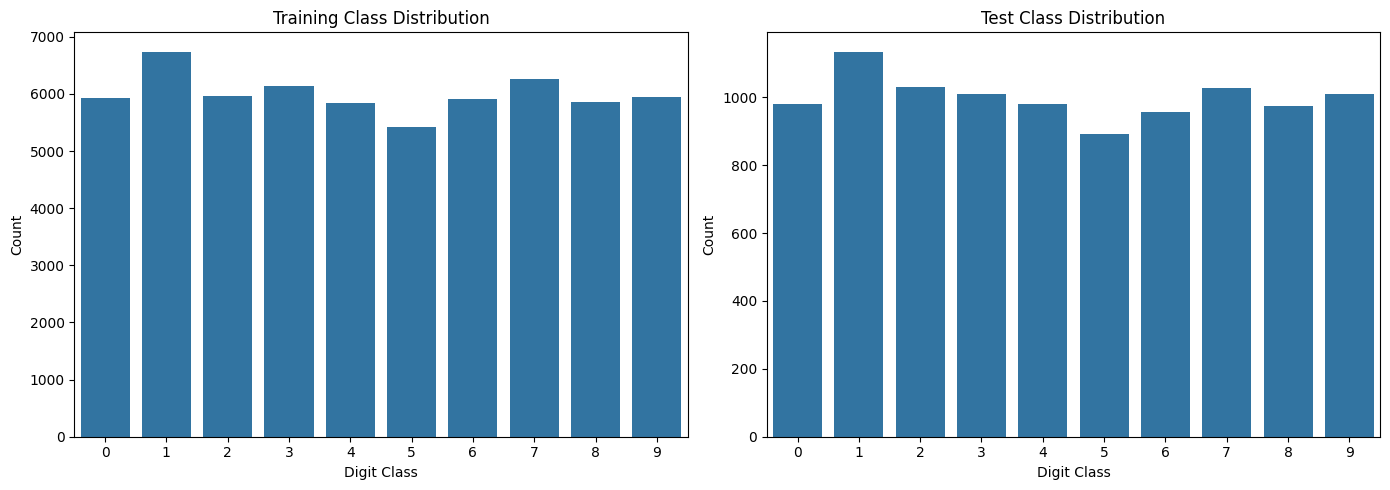

In [3]:
visualize_sample_images(x_train_raw, y_train)
plot_class_distribution(y_train, y_test)

## 4. Preprocessing

In [4]:
x_train, y_train_subset, x_test, y_test_subset = preprocess_data(
    x_train_raw, y_train, x_test_raw, y_test
)
print(x_train.shape, x_test.shape)


Preprocessing complete.
Training subset: (10000, 784)
Test subset: (2000, 784)
Feature vector dimension: 784
(10000, 784) (2000, 784)


## 5. Train MLP, SVM and KNN

In [5]:
mlp, mlp_pred, mlp_acc, mlp_time = train_mlp(
    x_train, y_train_subset, x_test, y_test_subset
)

svm, svm_pred, svm_acc, svm_time = train_svm(
    x_train, y_train_subset, x_test, y_test_subset
)

knn, knn_pred, knn_acc, knn_time = train_knn(
    x_train, y_train_subset, x_test, y_test_subset
)


Training MLP Neural Network...
MLP Training Time : 6.92s
MLP Accuracy      : 92.80%

Training SVM Classifier...
SVM Training Time : 14.80s
SVM Accuracy      : 93.10%

Training KNN Classifier...
KNN Training Time : 0.00s
KNN Accuracy      : 89.15%


## 6. Compare Models

In [6]:
results = pd.DataFrame({
    'Model': ['MLP Neural Network', 'SVM (RBF Kernel)', 'KNN (k=5)'],
    'Accuracy (%)': [mlp_acc * 100, svm_acc * 100, knn_acc * 100],
    'Training Time (s)': [mlp_time, svm_time, knn_time]
})
results

,Model,Accuracy (%),Training Time (s)
0,MLP Neural Network,92.80,6.924145
1,SVM (RBF Kernel),93.10,14.796422
2,KNN (k=5),89.15,0.004571


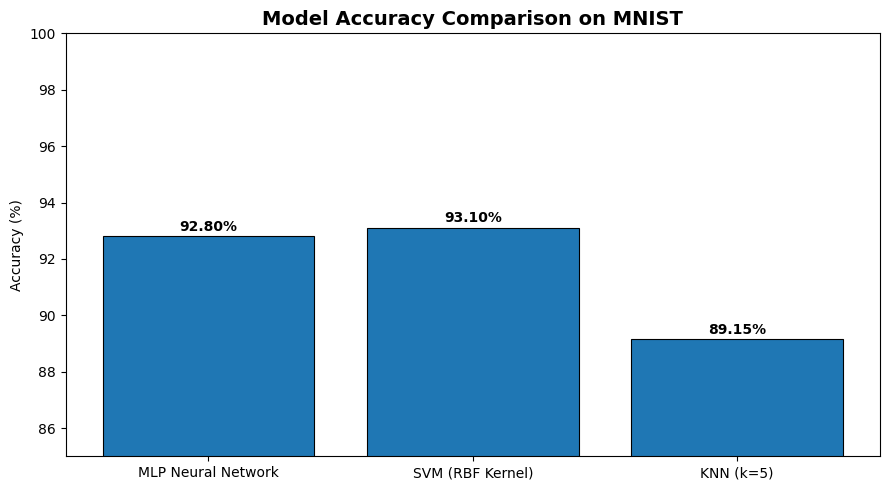

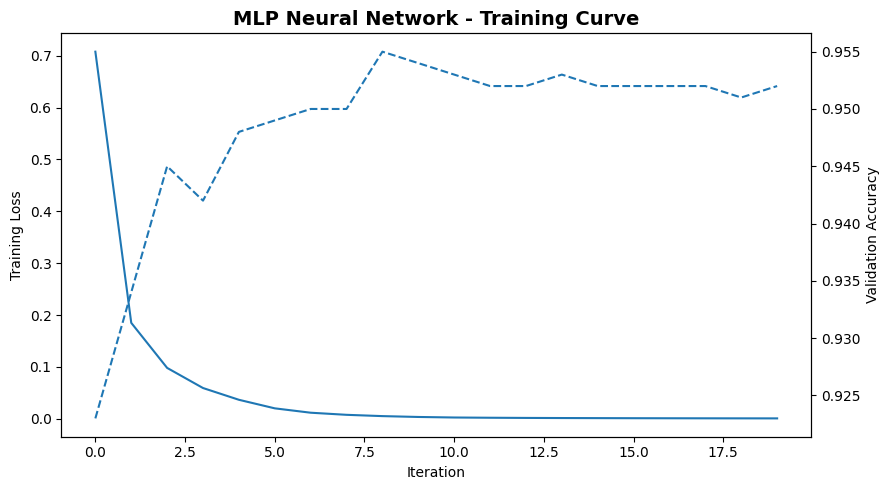

In [7]:
plot_accuracy_comparison(results)
plot_mlp_training_curve(mlp)

## 7. Confusion Matrices

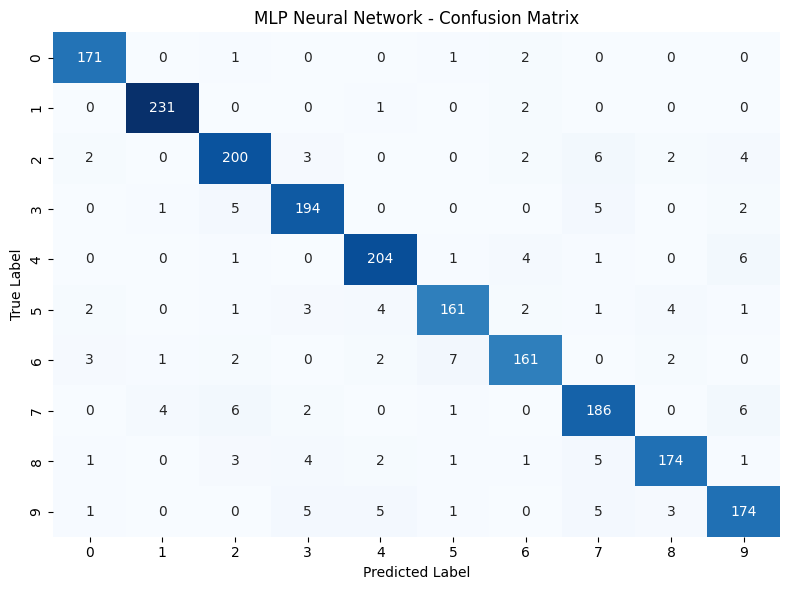

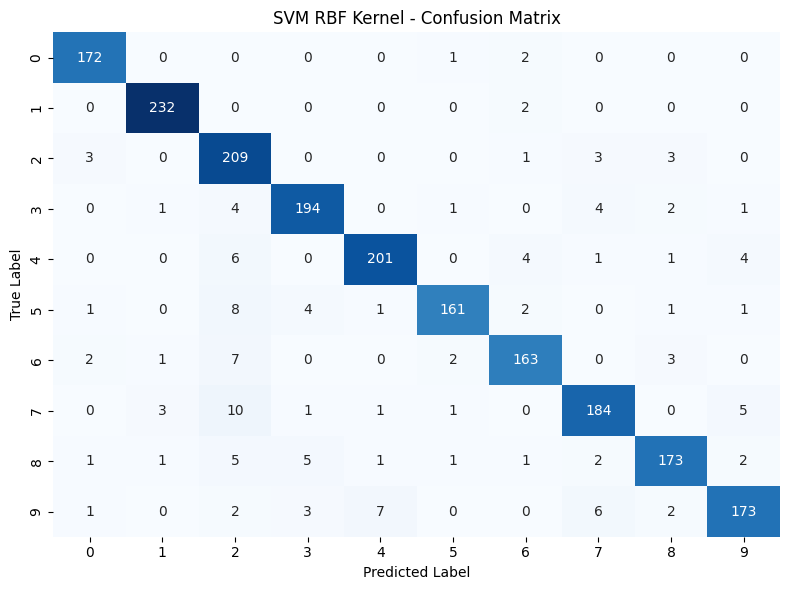

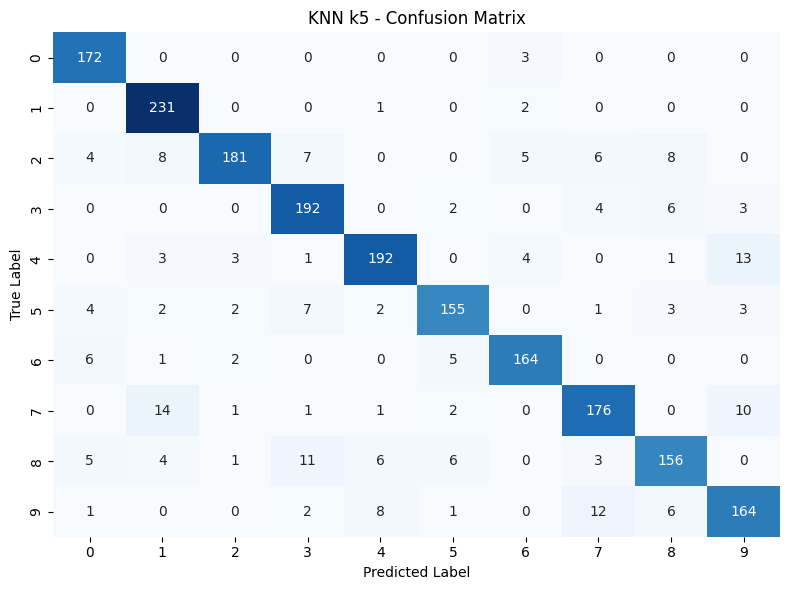

In [8]:
plot_confusion_matrix(y_test_subset, mlp_pred, 'MLP Neural Network')
plot_confusion_matrix(y_test_subset, svm_pred, 'SVM RBF Kernel')
plot_confusion_matrix(y_test_subset, knn_pred, 'KNN k5')

## Reported Results

The project report records MLP = 93.25%, SVM = 93.10%, and KNN = 89.15% on the 2,000-sample held-out subset. A fresh run may differ slightly.

## Interactive Demo

For the browser-based drawing demo, run from the repository root:

```bash
python src/train_model.py
streamlit run app.py
```

The demo converts a drawn digit to a 28×28 grayscale image, normalizes it, flattens it to 784 features, applies the saved StandardScaler and sends it to the saved MLP.

### Drawing preprocessing

The interactive app does not resize the complete 280×280 canvas directly. It detects the non-white handwriting, crops it, preserves its aspect ratio, fits it into a 20×20 region, centers it on a 28×28 black canvas, and then applies the same normalization and saved StandardScaler used by the MLP.